In [56]:
import numpy as np
import torch
from torch import nn
import gpytorch
from matplotlib import pyplot as plt
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution, IndependentMultitaskVariationalStrategy
from gpytorch.variational import VariationalStrategy

from utils import load_from_HDF, split_data, seed_worker, get_metric_func
from dataset import TranSiGenDataset
from tqdm import tqdm

In [3]:
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
data_path = '../data/LINCS2020/processed_data_id.h5'
data = load_from_HDF(data_path)

In [5]:
cell_count = len(set(data['cid']))
feat_type = 'KPGT'
batch_size = 64
learning_rate = 1e-3
beta = 0.1
dropout = 0.1
weight_decay = 1e-5
n_folds = 5
random_seed = 364039
split_type = 'smiles_split'
features_dim = 2304
features_embed_dim = [400]
n_latent = 100
# init_mode = 'pretrain_shRNA'
init_mode = 'random'
n_epochs = 300
molecule_path = '../data/LINCS2020/idx2smi.pickle'
input_dim = 978 + 2304 # Number of input dimensions
output_dim = 978  # Number of input dimensions

In [6]:
pair, pairv, pairt = split_data(data, n_folds=n_folds, split_type=split_type, rnds=random_seed)

In [7]:
train = TranSiGenDataset(
    LINCS_index=pair['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pair['canonical_smiles'],
    cid=pair['cid']
)

valid = TranSiGenDataset(
    LINCS_index=pairv['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pairv['canonical_smiles'],
    cid=pairv['cid']
)

test = TranSiGenDataset(
    LINCS_index=pairt['LINCS_index'],
    mol_feature_type=feat_type,
    mol_id=pairt['canonical_smiles'],
    cid=pairt['cid']
)

train_loader = torch.utils.data.DataLoader(dataset=train, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)
valid_loader = torch.utils.data.DataLoader(dataset=valid, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)
test_loader = torch.utils.data.DataLoader(dataset=test, batch_size=batch_size, shuffle=True, drop_last=False, num_workers=4, worker_init_fn=seed_worker)

In [39]:
num_latents = 20
num_tasks = output_dim

class MultitaskGPLayer(gpytorch.models.ApproximateGP):
    def __init__(self, num_latents, num_tasks, input_dim):
        # Inducing points now have input_dim dimensions
        inducing_points = torch.rand(num_latents, 16, input_dim)

        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2),
            batch_shape=torch.Size([num_latents])
        )

        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True
            ),
            num_tasks=num_tasks,
            num_latents=num_latents,
            latent_dim=-1  # This should point to the latent dimension
        )

        super().__init__(variational_strategy)

        # Mean and covariance modules remain similar but handle multi-input
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            # RBFKernel will automatically handle multi-dimensional inputs
            gpytorch.kernels.RBFKernel(ard_num_dims=input_dim, batch_shape=torch.Size([num_latents])),
            batch_shape=torch.Size([num_latents])
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
class DKLModel(nn.Module):
    def __init__(self, num_latents, num_tasks, input_dim):
        super(DKLModel, self).__init__()
        latent_dim = 100
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 2000),
            nn.BatchNorm1d(2000),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2000, 1000),
            nn.BatchNorm1d(1000),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(1000, 500),
            nn.BatchNorm1d(500),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(500, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )
        
        self.gp_layer = MultitaskGPLayer(num_latents, num_tasks, latent_dim)
        self.scale_to_bounds = gpytorch.utils.grid.ScaleToBounds(-1, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        features = self.scale_to_bounds(features)
        res = self.gp_layer(features)
        return res

model = DKLModel(num_latents, num_tasks, input_dim).to(dev)
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks).to(dev)

In [40]:
model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.feature_extractor.parameters()},
    {'params': model.gp_layer.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)

# Our loss object. We're using the VariationalELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model.gp_layer, num_data=len(train))

In [41]:
losses = []

In [44]:
epochs_iter = tqdm(range(50), desc="Epoch")
for i in epochs_iter:
    batch_loss = 0
    for x_batch, y_batch, mol_features, *_ in train_loader:
        optimizer.zero_grad()
        _input = torch.concat([x_batch, mol_features], dim=-1).to(dev)
        output = model(_input)
        loss = -mll(output, y_batch.to(dev))
        batch_loss += loss.item()
        loss.backward()
        optimizer.step()
    losses.append(batch_loss / len(train_loader))

Epoch: 100%|██████████| 50/50 [13:06<00:00, 15.74s/it]


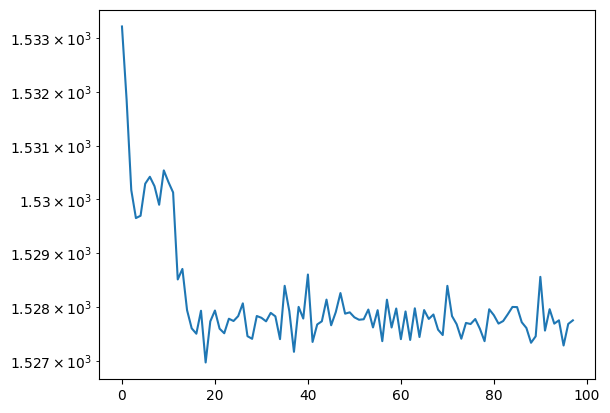

In [45]:
plt.plot(losses[2:])
plt.yscale('log')

In [46]:
losses

[1873.2880804716651,
 1536.5510288688836,
 1533.2164816785214,
 1531.8500951717797,
 1530.1752104843326,
 1529.654673851976,
 1529.6977991236113,
 1530.292544402455,
 1530.4217790994423,
 1530.2468437287991,
 1529.9015154275673,
 1530.5402727683493,
 1530.3229703864379,
 1530.130446952913,
 1528.5151107146264,
 1528.7103519931416,
 1527.9461620232466,
 1527.6082776922383,
 1527.5086222717202,
 1527.9344469171367,
 1526.9754386912207,
 1527.7374423271604,
 1527.938929398639,
 1527.6020920234587,
 1527.5171488085143,
 1527.78669413718,
 1527.7443749933748,
 1527.8351249125467,
 1528.0718975921175,
 1527.4628919500508,
 1527.4140384834527,
 1527.8372705011873,
 1527.8037674177938,
 1527.7381858463366,
 1527.894983589245,
 1527.8309306296112,
 1527.4083525244869,
 1528.39717356709,
 1527.927527998325,
 1527.17326680032,
 1528.0064473663288,
 1527.7902196006826,
 1528.6067507367284,
 1527.3564670102082,
 1527.6803959053277,
 1527.7392778538947,
 1528.1414324528812,
 1527.6652936379007,
 152

In [80]:
model.eval()
likelihood.eval()

results = {
    'pearson_x2_pred': [],
    'rmse_x2_pred': [],
    'pearson_deg_x_pred': [],
    'rmse_deg_x_pred': []
}

with torch.no_grad():
    for x_test, y_test, mol_feat_test, *_ in tqdm(test_loader):
        x_test = x_test.to(dev)
        mol_feat_test = mol_feat_test.to(dev)
        y_test = y_test.to(dev)
        observed_pred = likelihood(model(torch.concat([x_test, mol_feat_test], dim=-1)))
        
        for i in range(y_test.shape[0]):
            results['pearson_x2_pred'].append(
                get_metric_func('pearson')(observed_pred.mean[i].cpu().numpy(), y_test[i].cpu().numpy())
            )
            results['rmse_x2_pred'].append(
                get_metric_func('rmse')(observed_pred.mean[i].cpu().numpy(), y_test[i].cpu().numpy())
            )
            results['pearson_deg_x_pred'].append(
                get_metric_func('pearson')(
                    (observed_pred.mean[i] - x_test[i]).cpu().numpy(), (y_test[i] - x_test[i]).cpu().numpy()
                )
            )
            results['rmse_deg_x_pred'].append(
                get_metric_func('rmse')(
                    (observed_pred.mean[i] - x_test[i]).cpu().numpy(), (y_test[i] - x_test[i]).cpu().numpy()
                )
            )
    for key in results.keys():
        results[key] = np.array(results[key]).mean()
        

100%|██████████| 246/246 [00:34<00:00,  7.17it/s]


In [82]:
observed_pred_np = observed_pred.mean[:, 0].cpu().numpy()
stddev_np = observed_pred.stddev[:, 0].detach().cpu().numpy()

In [ ]:
x = np.linspace(0, observed_pred_np.shape[0], observed_pred_np.shape[0])
fig, ax = plt.subplots()
ax.plot(x, observed_pred_np, '-')
ax.fill_between(x, observed_pred_np - stddev_np, observed_pred_np + stddev_np, alpha=0.4)
ax.show()

In [84]:
results

{'pearson_x2_pred': np.float32(0.8314252),
 'rmse_x2_pred': np.float64(1.2416529090895716),
 'pearson_deg_x_pred': np.float32(0.25065327),
 'rmse_deg_x_pred': np.float64(1.2416529091402186)}

In [49]:
((test_x.to(dev) - observed_pred.mean) ** 2).mean()

tensor(1.4632, device='cuda:0')